# Sarah Cheulkar 23102C0060
## Customer Segmentation and Predictive Analytics Using Machine Learning
**R Programming Lab – Problem Statement 6 (implemented in Python / Google Colab)**

**Objective:** preprocess UCI Online Retail transactions, engineer customer-level RFM and purchasing features, compare K-Means and hierarchical clustering, visualize with PCA/Plotly, profile segments, and predict membership in a data-derived high-value segment using Random Forest and SVM.

**Run instructions:** Runtime → Run all. The dataset is fetched automatically; no manual upload is required. The first cell installs dependencies. Results are generated from the downloaded data and are not fabricated.

## 1. Problem statement and dataset
An e-commerce company wants meaningful customer segments and a model that predicts whether a customer belongs to a high-value category. The specified UCI Online Retail dataset contains 541,909 transactions with invoice, product, quantity, date, unit price, customer ID and country fields.

**Method note:** high-value is operationalized below as membership in the cluster with the highest mean customer monetary value. This is a target derived from clustering, not an independently supplied business label.

In [1]:
# 1. Setup: install and import
!pip -q install openpyxl scikit-learn scipy plotly

import os, zipfile, urllib.request, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from scipy.cluster.hierarchy import linkage, dendrogram
warnings.filterwarnings('ignore')
RANDOM_STATE=42
pd.set_option('display.max_columns', 50)
print("Setup complete")

Setup complete


## 2. Download and load data

In [2]:
# Automatic UCI download; no upload needed
url = "https://archive.ics.uci.edu/static/public/352/online+retail.zip"
zip_path = "/content/online_retail.zip"
try:
    urllib.request.urlretrieve(url, zip_path)
    with zipfile.ZipFile(zip_path) as z:
        files=[n for n in z.namelist() if n.lower().endswith(('.xlsx','.xls'))]
        if not files: raise FileNotFoundError("No Excel file found in UCI archive")
        z.extract(files[0], "/content")
    data_path="/content/"+files[0]
    raw=pd.read_excel(data_path)
except Exception as e:
    raise RuntimeError("Automatic UCI download failed. Check Colab internet access and rerun. Details: "+str(e))
print("Raw shape:", raw.shape)
display(raw.head())
display(raw.info())

Raw shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


None

## 3. Data quality checks and preprocessing

In [3]:
df=raw.copy()
df.columns=[str(c).strip().replace(' ','_') for c in df.columns]
required=['InvoiceNo','StockCode','Description','Quantity','InvoiceDate','UnitPrice','CustomerID','Country']
missing=[c for c in required if c not in df.columns]
if missing: raise ValueError(f"Expected columns not found: {missing}; actual: {df.columns.tolist()}")
print("Missing values before:")
display(df.isna().sum().to_frame("missing"))
# Remove rows without customer ID; normalize IDs and types
df=df.dropna(subset=['CustomerID']).copy()
df['CustomerID']=df['CustomerID'].astype(str).str.replace(r'\.0$','',regex=True)
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'], errors='coerce')
df['Quantity']=pd.to_numeric(df['Quantity'], errors='coerce')
df['UnitPrice']=pd.to_numeric(df['UnitPrice'], errors='coerce')
df=df.dropna(subset=['InvoiceDate','Quantity','UnitPrice'])
# Exclude cancellations (invoice numbers beginning C) and non-positive quantity/price
df=df[~df['InvoiceNo'].astype(str).str.upper().str.startswith('C')]
df=df[(df['Quantity']>0)&(df['UnitPrice']>0)].copy()
df['Revenue']=df['Quantity']*df['UnitPrice']
print("Cleaned shape:",df.shape)
print("Unique customers:",df.CustomerID.nunique())
print("Date range:",df.InvoiceDate.min(),"to",df.InvoiceDate.max())
display(df.describe(include='all').T.head(15))

Missing values before:


,missing
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


Cleaned shape: (397884, 9)
Unique customers: 4338
Date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
InvoiceNo,397884.0,18532.0,576339.0,542.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,397884,3665,85123A,2035,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,397884,3877,WHITE HANGING HEART T-LIGHT HOLDER,2028,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,397884.0,NaN,NaN,NaN,12.988238,1.0,2.0,6.0,12.0,80995.0,179.331775
InvoiceDate,397884,NaN,NaN,NaN,2011-07-10 23:41:23.511023360,2010-12-01 08:26:00,2011-04-07 11:12:00,2011-07-31 14:39:00,2011-10-20 14:33:00,2011-12-09 12:50:00,NaN
UnitPrice,397884.0,NaN,NaN,NaN,3.116488,0.001,1.25,1.95,3.75,8142.75,22.097877
CustomerID,397884,4338,17841,7847,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,397884,37,United Kingdom,354321,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Revenue,397884.0,NaN,NaN,NaN,22.397,0.001,4.68,11.8,19.8,168469.6,309.071041


## 4. Customer-level feature engineering (RFM + purchasing behavior)

In [4]:
snapshot=df['InvoiceDate'].max()+pd.Timedelta(days=1)
cust=df.groupby('CustomerID').agg(
    LastPurchase=('InvoiceDate','max'),
    Frequency=('InvoiceNo','nunique'),
    Monetary=('Revenue','sum'),
    TotalQuantity=('Quantity','sum'),
    MeanUnitPrice=('UnitPrice','mean'),
    UniqueProducts=('StockCode','nunique'),
    Countries=('Country','nunique')
)
cust['Recency']=(snapshot-cust['LastPurchase']).dt.days
cust['AvgTransactionValue']=cust['Monetary']/cust['Frequency'].replace(0,np.nan)
cust['PurchaseFrequency']=cust['Frequency']/((snapshot-cust['LastPurchase']).dt.days+1)
cust=cust.replace([np.inf,-np.inf],np.nan).dropna()
features=['Recency','Frequency','Monetary','AvgTransactionValue','TotalQuantity','MeanUnitPrice','UniqueProducts','PurchaseFrequency']
X=cust[features].copy()
print("Customer feature matrix:",X.shape)
display(cust[features].describe().T)

Customer feature matrix: (4338, 8)


,count,mean,std,min,25%,50%,75%,max
Recency,4338.0,92.536422,100.014169,1.000000,18.000000,51.000000,142.000000,374.00
Frequency,4338.0,4.272015,7.697998,1.000000,1.000000,2.000000,5.000000,209.00
Monetary,4338.0,2054.266460,8989.230441,3.750000,307.415000,674.485000,1661.740000,280206.02
AvgTransactionValue,4338.0,419.166289,1796.537944,3.450000,178.625000,293.900000,430.113750,84236.25
TotalQuantity,4338.0,1191.289073,5046.081546,1.000000,160.000000,379.000000,992.750000,196915.00
MeanUnitPrice,4338.0,4.467773,34.211451,0.122500,2.203728,2.917611,3.829784,2033.10
UniqueProducts,4338.0,61.501153,85.366768,1.000000,16.000000,35.000000,77.000000,1787.00
PurchaseFrequency,4338.0,0.535110,2.985156,0.002667,0.012048,0.044944,0.212121,104.50


## 5. Outlier treatment, log transform and scaling
Highly skewed spend/count variables are clipped at the 1st/99th percentiles, then nonnegative skewed variables are log1p transformed. Recency remains in days. Scaling is fitted on the customer feature matrix.

In [5]:
# Winsorize extreme values to reduce leverage of exceptional customers
clip_cols=features
Xw=X.copy()
for c in clip_cols:
    lo,hi=Xw[c].quantile([.01,.99])
    Xw[c]=Xw[c].clip(lo,hi)
# Log transform nonnegative, right-skewed features
log_cols=['Frequency','Monetary','AvgTransactionValue','TotalQuantity','MeanUnitPrice','UniqueProducts','PurchaseFrequency']
for c in log_cols: Xw[c]=np.log1p(Xw[c].clip(lower=0))
scaler=StandardScaler()
X_scaled=scaler.fit_transform(Xw)
print("Scaled matrix:",X_scaled.shape,"; all finite:",np.isfinite(X_scaled).all())

Scaled matrix: (4338, 8) ; all finite: True


## 6. K-Means and Elbow Method
Evaluate candidate k values with inertia and silhouette score. Select k by the maximum silhouette among the tested values (alongside the elbow curve for visual assessment).

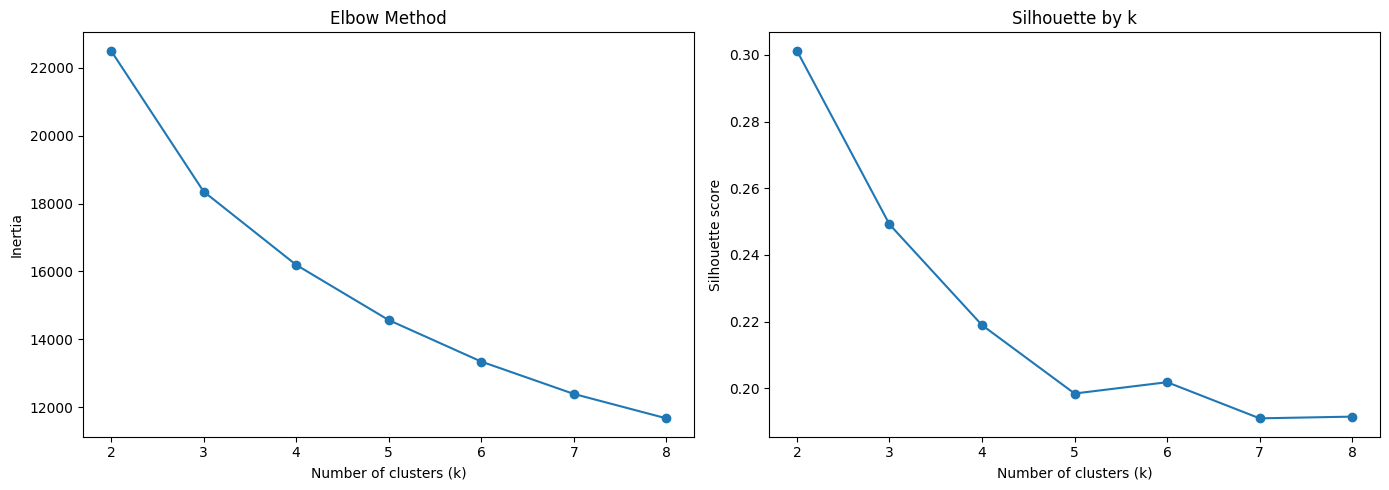

Selected k (highest tested silhouette): 2
K-Means silhouette: 0.3013


In [6]:
ks=range(2,9)
inertias=[]; sils=[]
for k in ks:
    km=KMeans(n_clusters=k,random_state=RANDOM_STATE,n_init=10)
    labels=km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_scaled,labels, sample_size=min(10000,len(X_scaled)),random_state=RANDOM_STATE))
fig,ax=plt.subplots(1,2,figsize=(14,5))
ax[0].plot(list(ks),inertias,marker='o'); ax[0].set(title='Elbow Method',xlabel='Number of clusters (k)',ylabel='Inertia')
ax[1].plot(list(ks),sils,marker='o'); ax[1].set(title='Silhouette by k',xlabel='Number of clusters (k)',ylabel='Silhouette score')
plt.tight_layout(); plt.show()
best_k=list(ks)[int(np.argmax(sils))]
print("Selected k (highest tested silhouette):",best_k)
kmeans=KMeans(n_clusters=best_k,random_state=RANDOM_STATE,n_init=10)
cust['KMeansCluster']=kmeans.fit_predict(X_scaled)
kmeans_sil=silhouette_score(X_scaled,cust.KMeansCluster,sample_size=min(10000,len(cust)),random_state=RANDOM_STATE)
print("K-Means silhouette:",round(kmeans_sil,4))

## 7. Hierarchical clustering and dendrogram
For computational feasibility, hierarchical clustering and its dendrogram use a reproducible sample (up to 1,500 customers). The comparison silhouette is calculated on that same sample.

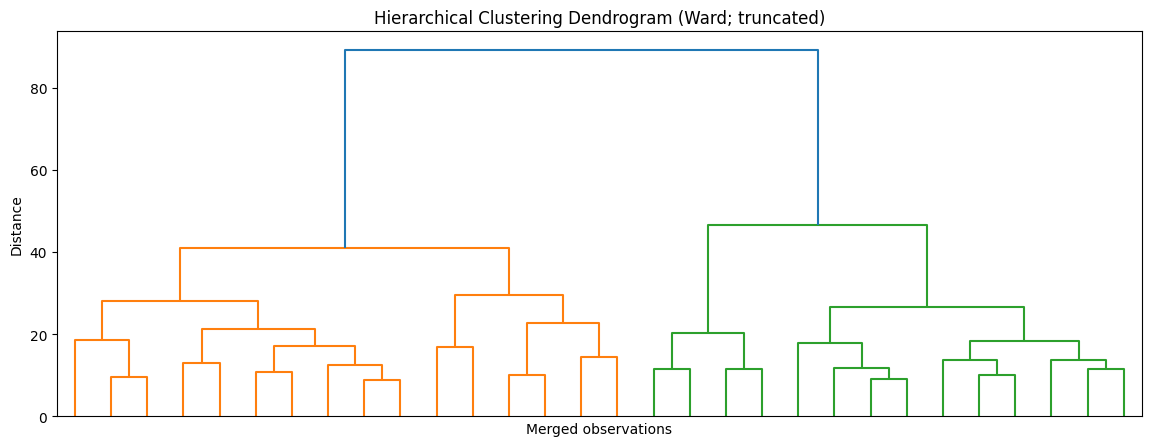

,Method,Silhouette
0,K-Means (sample),0.296646
1,Hierarchical Ward (sample),0.282941


In [7]:
from scipy.cluster.hierarchy import linkage, dendrogram
n_h=min(1500,len(cust))
sample_idx=np.random.RandomState(RANDOM_STATE).choice(len(cust),n_h,replace=False)
Xh=X_scaled[sample_idx]
Z=linkage(Xh,method='ward')
plt.figure(figsize=(14,5))
dendrogram(Z,no_labels=True,truncate_mode='lastp',p=30)
plt.title('Hierarchical Clustering Dendrogram (Ward; truncated)'); plt.xlabel('Merged observations'); plt.ylabel('Distance'); plt.show()
hier=AgglomerativeClustering(n_clusters=best_k,linkage='ward')
hlabels=hier.fit_predict(Xh)
hier_sil=silhouette_score(Xh,hlabels,sample_size=min(10000,len(Xh)),random_state=RANDOM_STATE)
km_sample=KMeans(n_clusters=best_k,random_state=RANDOM_STATE,n_init=10).fit_predict(Xh)
km_sample_sil=silhouette_score(Xh,km_sample)
comparison=pd.DataFrame({'Method':['K-Means (sample)','Hierarchical Ward (sample)'],
                         'Silhouette':[km_sample_sil,hier_sil]})
display(comparison)

## 8. PCA visualization and cluster profiles

PCA explained variance ratio: [0.54485277 0.14497934] total: 0.6898


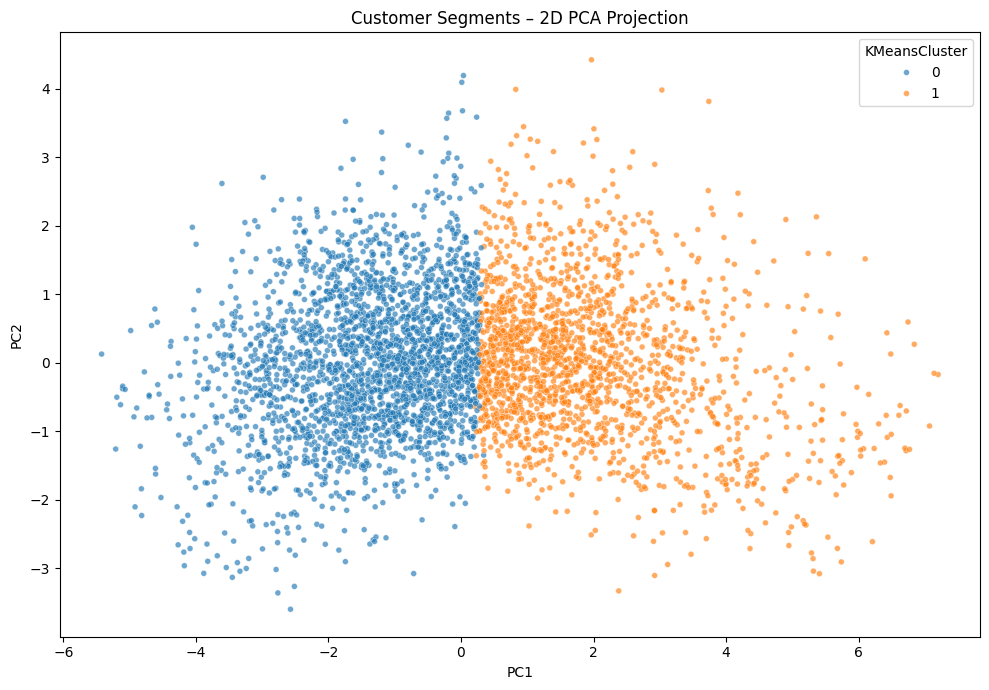

,Recency,Frequency,Monetary,AvgTransactionValue,TotalQuantity,MeanUnitPrice,UniqueProducts,PurchaseFrequency,Customers,Share_%
KMeansCluster,,,,,,,,,,
1,21.0,5.0,1992.11,375.59,1176.0,2.84,86.0,0.25,1801,41.5
0,94.0,1.0,344.33,219.63,189.0,2.99,20.0,0.02,2537,58.5


In [8]:
pca=PCA(n_components=2,random_state=RANDOM_STATE)
pcs=pca.fit_transform(X_scaled)
cust['PC1']=pcs[:,0]; cust['PC2']=pcs[:,1]
print("PCA explained variance ratio:",pca.explained_variance_ratio_,
      "total:",pca.explained_variance_ratio_.sum().round(4))
plt.figure(figsize=(10,7))
sns.scatterplot(data=cust,x='PC1',y='PC2',hue='KMeansCluster',palette='tab10',s=18,alpha=.65)
plt.title('Customer Segments – 2D PCA Projection'); plt.tight_layout(); plt.show()
profile=cust.groupby('KMeansCluster')[features].median().round(2)
profile['Customers']=cust.groupby('KMeansCluster').size()
profile['Share_%']=(profile.Customers/len(cust)*100).round(1)
display(profile.sort_values('Monetary',ascending=False))

## 9. Identify high-value segment and prepare prediction target
The cluster with the largest median Monetary value is labeled high-value. To avoid leakage, cluster labels are used only to define the target; supervised models use customer features, not the cluster ID or PCA coordinates.

In [9]:
high_cluster=int(profile['Monetary'].idxmax())
cust['HighValue']=(cust['KMeansCluster']==high_cluster).astype(int)
print("High-value cluster:",high_cluster)
print(cust.HighValue.value_counts().rename(index={0:'Other',1:'High value'}))
X_model=cust[features].copy()
y=cust['HighValue']
X_train,X_test,y_train,y_test=train_test_split(X_model,y,test_size=.25,random_state=RANDOM_STATE,stratify=y)
print("Train:",X_train.shape,"Test:",X_test.shape)

High-value cluster: 1
HighValue
Other         2537
High value    1801
Name: count, dtype: int64
Train: (3253, 8) Test: (1085, 8)


## 10. Random Forest and SVM evaluation

\n Random Forest
              precision    recall  f1-score   support

       Other       0.98      0.98      0.98       635
  High value       0.98      0.96      0.97       450

    accuracy                           0.98      1085
   macro avg       0.98      0.97      0.98      1085
weighted avg       0.98      0.98      0.98      1085



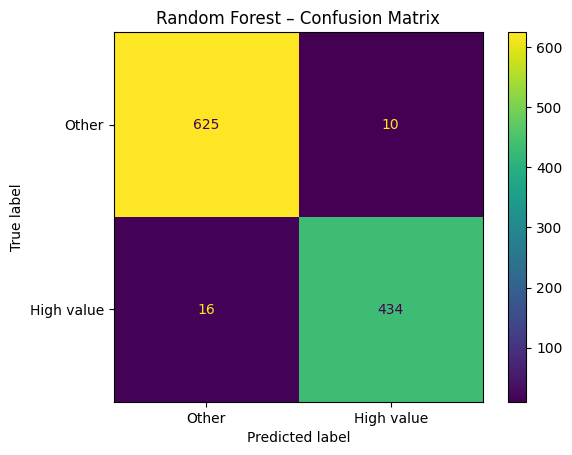

\n SVM (RBF)
              precision    recall  f1-score   support

       Other       0.97      0.96      0.97       635
  High value       0.95      0.96      0.95       450

    accuracy                           0.96      1085
   macro avg       0.96      0.96      0.96      1085
weighted avg       0.96      0.96      0.96      1085



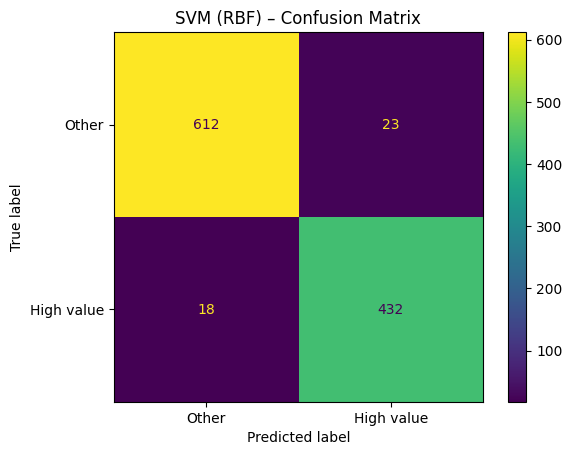

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Random Forest,0.9760,0.9775,0.9644,0.9709,0.9985
SVM (RBF),0.9622,0.9495,0.9600,0.9547,0.9943


In [10]:
models={
 'Random Forest':Pipeline([('scale',StandardScaler()),('model',RandomForestClassifier(n_estimators=300,class_weight='balanced',random_state=RANDOM_STATE,n_jobs=-1))]),
 'SVM (RBF)':Pipeline([('scale',StandardScaler()),('model',SVC(kernel='rbf',probability=True,class_weight='balanced',random_state=RANDOM_STATE))])
}
fitted={}; rows=[]
for name,model in models.items():
    model.fit(X_train,y_train); fitted[name]=model
    pred=model.predict(X_test); prob=model.predict_proba(X_test)[:,1]
    rows.append({'Model':name,'Accuracy':accuracy_score(y_test,pred),
                 'Precision':precision_score(y_test,pred,zero_division=0),
                 'Recall':recall_score(y_test,pred,zero_division=0),
                 'F1':f1_score(y_test,pred,zero_division=0),
                 'ROC-AUC':roc_auc_score(y_test,prob)})
    print("\\n",name); print(classification_report(y_test,pred,target_names=['Other','High value'],zero_division=0))
    ConfusionMatrixDisplay(confusion_matrix(y_test,pred),display_labels=['Other','High value']).plot()
    plt.title(name+' – Confusion Matrix'); plt.show()
metrics=pd.DataFrame(rows).set_index('Model').round(4)
display(metrics)

## 11. ROC curves and feature importance

<Figure size 800x600 with 0 Axes>

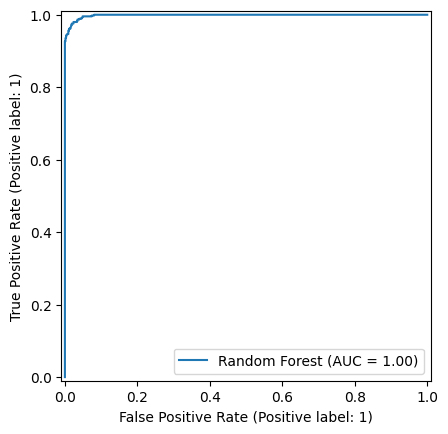

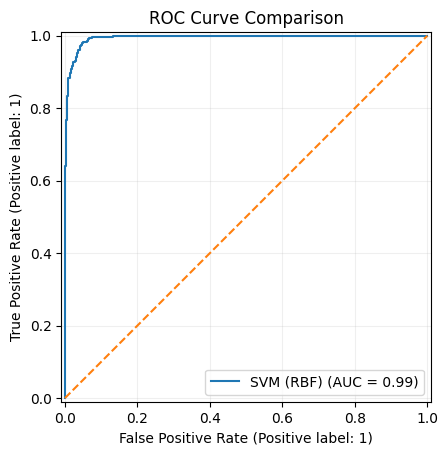

,Importance
Monetary,0.334647
TotalQuantity,0.229998
Frequency,0.132943
UniqueProducts,0.106486
PurchaseFrequency,0.102705
Recency,0.044401
AvgTransactionValue,0.033981
MeanUnitPrice,0.014840


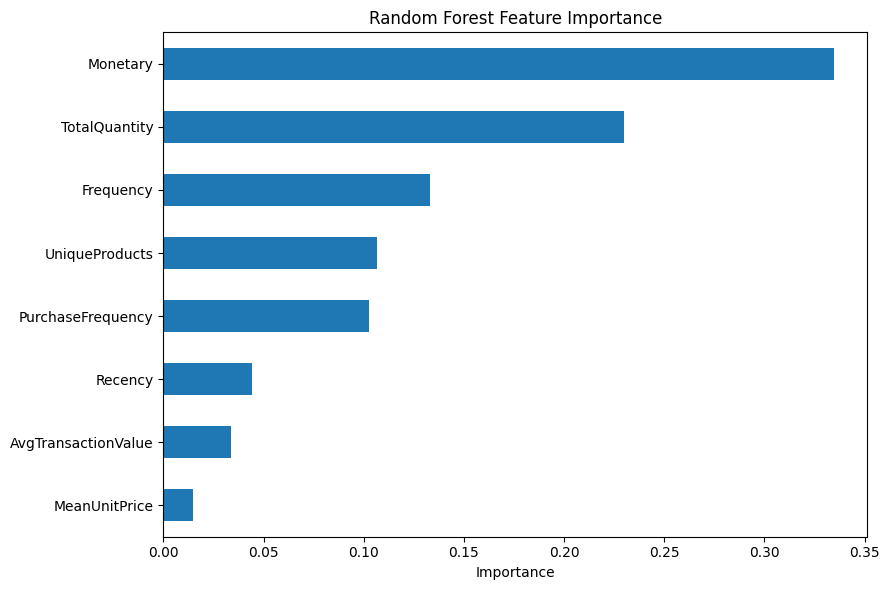

In [11]:
from sklearn.metrics import RocCurveDisplay
plt.figure(figsize=(8,6))
for name,model in fitted.items():
    RocCurveDisplay.from_estimator(model,X_test,y_test,name=name)
plt.plot([0,1],[0,1],'--',label='Chance'); plt.title('ROC Curve Comparison'); plt.grid(alpha=.2); plt.show()
rf=fitted['Random Forest'].named_steps['model']
importance=pd.Series(rf.feature_importances_,index=features).sort_values()
display(importance.sort_values(ascending=False).to_frame('Importance'))
importance.plot(kind='barh',figsize=(9,6),title='Random Forest Feature Importance'); plt.xlabel('Importance'); plt.tight_layout(); plt.show()

## 12. Interactive 3D cluster visualization (Plotly)

In [12]:
pca3=PCA(n_components=3,random_state=RANDOM_STATE)
pc3=pca3.fit_transform(X_scaled)
viz=cust[['KMeansCluster']].copy()
viz['PC1']=pc3[:,0]; viz['PC2']=pc3[:,1]; viz['PC3']=pc3[:,2]
# Plotly renders interactively in Colab; sample for browser responsiveness
viz_sample=viz.sample(min(5000,len(viz)),random_state=RANDOM_STATE)
fig=px.scatter_3d(viz_sample,x='PC1',y='PC2',z='PC3',color=viz_sample['KMeansCluster'].astype(str),
                  title='Interactive 3D Customer Clusters (PCA)')
fig.show()

## 13. Segment-wise marketing recommendations

In [13]:
# Data-driven summaries and actionable segment recommendations
med=profile.copy()
for cl,row in med.iterrows():
    print(f"\\nCLUSTER {cl} | customers={int(row['Customers'])} ({row['Share_%']}%)")
    print("Median RFM/behavior:",row[features].to_dict())
    if cl==high_cluster:
        print("Suggested action: loyalty/VIP benefits, early access, personalized cross-sell; protect retention and monitor margin.")
    elif row['Recency']>profile['Recency'].median():
        print("Suggested action: win-back sequence, personalized reminders, limited-time return incentive; test incrementality.")
    elif row['Frequency']<profile['Frequency'].median():
        print("Suggested action: onboarding and second-purchase offers; recommend complementary products.")
    else:
        print("Suggested action: relevant bundles, category discovery, and frequency-building campaigns; avoid excessive discounting.")

\nCLUSTER 0 | customers=2537 (58.5%)
Median RFM/behavior: {'Recency': 94.0, 'Frequency': 1.0, 'Monetary': 344.33, 'AvgTransactionValue': 219.63, 'TotalQuantity': 189.0, 'MeanUnitPrice': 2.99, 'UniqueProducts': 20.0, 'PurchaseFrequency': 0.02}
Suggested action: win-back sequence, personalized reminders, limited-time return incentive; test incrementality.
\nCLUSTER 1 | customers=1801 (41.5%)
Median RFM/behavior: {'Recency': 21.0, 'Frequency': 5.0, 'Monetary': 1992.11, 'AvgTransactionValue': 375.59, 'TotalQuantity': 1176.0, 'MeanUnitPrice': 2.84, 'UniqueProducts': 86.0, 'PurchaseFrequency': 0.25}
Suggested action: loyalty/VIP benefits, early access, personalized cross-sell; protect retention and monitor margin.


## 14. Interpretation, limitations, and conclusion

### Interpretation guide
- **Elbow curve:** look for diminishing returns in inertia as k increases; the selected k is also informed by the tested silhouette values.
- **Silhouette:** values closer to 1 indicate better separation; values near 0 indicate overlap, and negative values can indicate questionable assignments.
- **Profiles:** compare median Recency, Frequency, Monetary and other features to describe each segment. Cluster numbers are arbitrary identifiers, not ranks.
- **Prediction:** compare Accuracy, Precision, Recall, F1 and ROC-AUC together, with confusion matrices showing error types. The high-value class is defined from this dataset's clustering.

### Limitations
1. The data is historical and covers a limited retail context; behavior may not generalize to other businesses or periods.
2. Cancellations and nonpositive quantity/price records are excluded; missing customer IDs are removed.
3. Outlier clipping and log transformation change feature distributions.
4. Cluster-derived labels are proxies, not verified lifetime value or profitability labels. A real deployment should define value using future-period revenue/margin and validate temporally.
5. Hierarchical clustering is sampled for tractability; its silhouette is compared on the same sample as K-Means.
6. PCA is a visualization/dimensionality-reduction view; axes are combinations of original features and may not be directly interpretable.

### Conclusion
This notebook implements the requested end-to-end workflow: transaction cleaning, customer feature engineering, K-Means and Ward hierarchical clustering, silhouette evaluation, PCA, cluster profiling, high-value target construction, Random Forest/SVM evaluation, feature importance, interactive 3D visualization, and segment-specific marketing ideas. Run all cells in Colab to populate the actual dataset-specific results.